<a href="https://colab.research.google.com/github/handeunaldi/dsa-210-project/blob/main/ml_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Models

**Project:** *Economic Development and Health Outcomes: GDP, Healthcare Spending, and Life Expectancy*

This notebook focuses on the machine learning component of the project. The main objective is to predict **life expectancy at birth** using economic and healthcare-related indicators.

The analysis includes:

1. **Regression task:** Predict life expectancy using GDP per capita, healthcare expenditure per capita, year, region, and country information.
2. **Model comparison:** Compare baseline, linear, regularized, tree-based, and ensemble models.
3. **Time-aware evaluation:** Train models on earlier years and test them on more recent years to reduce temporal leakage.
4. **Random Forest tuning:** Improve the main model using GridSearchCV.
5. **Model interpretation:** Analyze feature importance, residuals, and country-year observations with the largest prediction errors.
6. **Optional classification task:** Classify countries into low, middle, and high life expectancy groups.

The machine learning analysis complements the statistical analysis by testing whether economic development and healthcare investment are useful predictors of population health outcomes.

In [1]:
# ===== 0) Imports & Helpers =====

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    learning_curve
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

np.random.seed(42)

os.makedirs("figures", exist_ok=True)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def safe_ohe():
    """Create OneHotEncoder compatible with different sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

## 1) Load the Datasets

Three datasets are used in this project:

- Life expectancy at birth
- GDP per capita
- Current healthcare expenditure per capita

The datasets are merged by country, country code, and year. This creates a country-year panel dataset that can be used for machine learning.

The target variable is **life expectancy**, and the main predictors are **GDP per capita** and **healthcare expenditure per capita**.

In [2]:
# ===== 1) Load raw datasets =====

life_df = pd.read_csv("life-expectancy.csv")
gdp_df = pd.read_csv("gdp-per-capita-worldbank.csv")
health_df = pd.read_csv("annual-healthcare-expenditure-per-capita.csv")

print("Life expectancy shape:", life_df.shape)
print("GDP shape:", gdp_df.shape)
print("Healthcare expenditure shape:", health_df.shape)

display(life_df.head())
display(gdp_df.head())
display(health_df.head())

Life expectancy shape: (21565, 4)
GDP shape: (7240, 5)
Healthcare expenditure shape: (4869, 4)


,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,1950,28.1563
1,Afghanistan,AFG,1951,28.5836
2,Afghanistan,AFG,1952,29.0138
3,Afghanistan,AFG,1953,29.4521
4,Afghanistan,AFG,1954,29.6975


,Entity,Code,Year,GDP per capita,World region according to OWID
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


,Entity,Code,Year,"Current health expenditure per capita, PPP (current international $)"
0,Afghanistan,AFG,2002,85.857500
1,Afghanistan,AFG,2003,85.933020
2,Afghanistan,AFG,2004,93.935810
3,Afghanistan,AFG,2005,105.927704
4,Afghanistan,AFG,2006,118.405820


## 2) Clean Column Names and Merge Datasets

Since the three datasets come from different sources, the variable names are standardized before merging.

The merged dataset keeps observations where life expectancy, GDP per capita, and healthcare expenditure are all available. Rows with missing target or predictor values are removed because the machine learning models require complete information for training and testing.

In [3]:
# ===== 2) Standardize column names =====

life_df = life_df.rename(columns={
    "Life expectancy": "life_expectancy"
})

gdp_df = gdp_df.rename(columns={
    "GDP per capita": "gdp_per_capita",
    "World region according to OWID": "region"
})

health_df = health_df.rename(columns={
    "Current health expenditure per capita, PPP (current international $)": "health_expenditure_per_capita"
})

# Merge life expectancy and GDP
merged_df = pd.merge(
    life_df,
    gdp_df[["Entity", "Code", "Year", "gdp_per_capita", "region"]],
    on=["Entity", "Code", "Year"],
    how="inner"
)

# Merge healthcare expenditure
merged_df = pd.merge(
    merged_df,
    health_df[["Entity", "Code", "Year", "health_expenditure_per_capita"]],
    on=["Entity", "Code", "Year"],
    how="inner"
)

# Drop missing values in core variables
core_cols = [
    "Entity",
    "Code",
    "Year",
    "life_expectancy",
    "gdp_per_capita",
    "health_expenditure_per_capita",
    "region"
]

merged_df = merged_df.dropna(subset=core_cols).copy()

# Sort as panel data
merged_df = merged_df.sort_values(["Entity", "Year"]).reset_index(drop=True)

print("Merged dataset shape:", merged_df.shape)
display(merged_df.head())
display(merged_df.describe())

Merged dataset shape: (4401, 7)


,Entity,Code,Year,life_expectancy,gdp_per_capita,region,health_expenditure_per_capita
0,Afghanistan,AFG,2002,56.2251,1774.3087,Asia,85.857500
1,Afghanistan,AFG,2003,57.1713,1815.9282,Asia,85.933020
2,Afghanistan,AFG,2004,57.8098,1776.9182,Asia,93.935810
3,Afghanistan,AFG,2005,58.2468,1908.1147,Asia,105.927704
4,Afghanistan,AFG,2006,58.5533,1929.7239,Asia,118.405820


,Year,life_expectancy,gdp_per_capita,health_expenditure_per_capita
count,4401.000000,4401.000000,4401.000000,4401.000000
mean,2011.565553,70.187741,21874.256090,1236.375379
std,6.905850,8.687661,23578.105834,1626.673518
min,2000.000000,14.665500,711.976400,6.106393
25%,2006.000000,64.714800,4846.862300,180.343750
50%,2012.000000,71.536600,13250.566000,588.723200
75%,2018.000000,76.599500,30920.330000,1592.092300
max,2023.000000,85.708200,145590.770000,13473.193000


## 3) Feature Engineering

GDP per capita and healthcare expenditure per capita usually have skewed distributions because a small number of countries have very high values. To reduce the influence of extreme values, logarithmic transformations are added.

The model uses both original and log-transformed versions of the economic variables. This allows the model to capture patterns in both absolute values and proportional differences.

Additional panel-based features are also created:

- `gdp_to_health_ratio`: GDP per capita divided by healthcare expenditure per capita
- `health_share_proxy`: healthcare expenditure per capita divided by GDP per capita
- `life_expectancy_lag1`: previous year's life expectancy for the same country
- `life_expectancy_change`: yearly change in life expectancy

The lag and change variables help capture the time structure of the country-year panel.

In [4]:
# ===== 3) Feature engineering =====

merged_df["log_gdp_per_capita"] = np.log1p(merged_df["gdp_per_capita"])
merged_df["log_health_expenditure_per_capita"] = np.log1p(merged_df["health_expenditure_per_capita"])

merged_df["gdp_to_health_ratio"] = (
    merged_df["gdp_per_capita"] / merged_df["health_expenditure_per_capita"]
)

merged_df["health_share_proxy"] = (
    merged_df["health_expenditure_per_capita"] / merged_df["gdp_per_capita"]
)

# Replace infinite values created by division issues
merged_df = merged_df.replace([np.inf, -np.inf], np.nan)

# Panel features
merged_df["life_expectancy_lag1"] = merged_df.groupby("Entity")["life_expectancy"].shift(1)
merged_df["life_expectancy_change"] = (
    merged_df["life_expectancy"] - merged_df["life_expectancy_lag1"]
)

# We will use lag/change only for interpretation and optional tasks.
# For the main prediction model, we avoid using life_expectancy_lag1
# because it can make the prediction task too easy and may reduce interpretability.

display(merged_df.head())

,Entity,Code,Year,life_expectancy,gdp_per_capita,region,health_expenditure_per_capita,log_gdp_per_capita,log_health_expenditure_per_capita,gdp_to_health_ratio,health_share_proxy,life_expectancy_lag1,life_expectancy_change
0,Afghanistan,AFG,2002,56.2251,1774.3087,Asia,85.857500,7.481730,4.464269,20.665739,0.048389,NaN,NaN
1,Afghanistan,AFG,2003,57.1713,1815.9282,Asia,85.933020,7.504903,4.465138,21.131902,0.047322,56.2251,0.9462
2,Afghanistan,AFG,2004,57.8098,1776.9182,Asia,93.935810,7.483198,4.553201,18.916303,0.052864,57.1713,0.6385
3,Afghanistan,AFG,2005,58.2468,1908.1147,Asia,105.927704,7.554395,4.672153,18.013368,0.055514,57.8098,0.4370
4,Afghanistan,AFG,2006,58.5533,1929.7239,Asia,118.405820,7.565650,4.782528,16.297543,0.061359,58.2468,0.3065


## 4) Time-Aware Train/Test Split

A time-aware split is used instead of a random split. This means the model is trained on earlier years and tested on the most recent years.

This approach is more realistic for panel data because it evaluates whether the model can generalize from the past to newer observations. It also reduces the risk of temporal leakage.

The last two years in the dataset are used as the test set.

In [5]:
# ===== 4) Time-aware train/test split =====

years = sorted(merged_df["Year"].dropna().unique())

if len(years) < 4:
    raise ValueError("Not enough years for a time-aware split.")

test_years = years[-2:]

train_df = merged_df[~merged_df["Year"].isin(test_years)].copy()
test_df = merged_df[merged_df["Year"].isin(test_years)].copy()

print("Test years:", test_years)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Test years: [np.int64(2022), np.int64(2023)]
Train shape: (4034, 13)
Test shape: (367, 13)


## 5) Preprocessing Pipeline

The dataset contains both numerical and categorical variables.

Numerical variables are processed with:

- Median imputation for missing values
- Standard scaling

Categorical variables are processed with:

- Most frequent imputation
- One-hot encoding

Using a pipeline prevents data leakage because preprocessing steps are learned only from the training data.

**Lightweight adjustment:** Country names are excluded from the categorical predictors. This reduces runtime and prevents the model from memorizing country-specific patterns. Region information is kept as a broader geographic feature.


In [19]:
# ===== 5) Define features and preprocessing =====

# Entity (country name) is excluded to reduce computation time and avoid country-level memorization.
# Region is kept as a broader geographic categorical feature.

numeric_features = [
    "Year",
    "gdp_per_capita",
    "health_expenditure_per_capita",
    "log_gdp_per_capita",
    "log_health_expenditure_per_capita",
    "gdp_to_health_ratio",
    "health_share_proxy"
]

categorical_features = [
    "region"
]

target = "life_expectancy"

X_train = train_df[numeric_features + categorical_features].copy()
y_train = train_df[target].astype(float)

X_test = test_df[numeric_features + categorical_features].copy()
y_test = test_df[target].astype(float)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", safe_ohe())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Categorical features used:", categorical_features)

X_train shape: (4034, 8)
X_test shape: (367, 8)
Categorical features used: ['region']


## 6) Regression Model Zoo

Several regression models are compared before selecting the final model. This is important because it prevents the analysis from relying on one model without justification.

The tested models include:

- Dummy Regressor as a baseline
- Linear Regression
- Ridge Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- SVR

The Dummy Regressor predicts the average life expectancy and acts as a minimum-performance benchmark. A useful model should perform clearly better than this baseline.

**Lightweight adjustment:** The slowest models are removed from the model zoo so that the notebook runs faster in Colab. The comparison still includes a baseline, linear model, regularized model, decision tree, and Random Forest.


In [20]:
# ===== 6) Regression model zoo =====

# This version keeps the main comparison logic but removes the slowest models.


reg_models = {
    "Baseline Dummy": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
}

rows = []
trained_pipelines = {}

for name, model in reg_models.items():
    print(f"Training {name}...")

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rows.append({
        "Model": name,
        "RMSE": rmse(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

    trained_pipelines[name] = pipe

model_results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

display(model_results)

Training Baseline Dummy...
Training Linear Regression...
Training Ridge Regression...
Training Decision Tree...
Training Random Forest...


,Model,RMSE,MAE,R2
0,Random Forest,4.001019,2.606884,0.718387
1,Ridge Regression,4.257595,3.015093,0.681110
2,Linear Regression,4.297406,3.024606,0.675119
3,Decision Tree,4.600134,3.169533,0.627735
4,Baseline Dummy,8.044392,6.551960,-0.138408


## 7) Model Comparison Interpretation

The model comparison table evaluates how well each model predicts life expectancy on the most recent years.

The most important comparison is against the Dummy Regressor. If the machine learning models perform better than the baseline, this suggests that the selected predictors contain meaningful information about life expectancy.

Random Forest is the main model of interest because it can capture non-linear relationships between economic development, healthcare spending, and life expectancy. However, the final selection should still be based on performance metrics such as RMSE, MAE, and R².

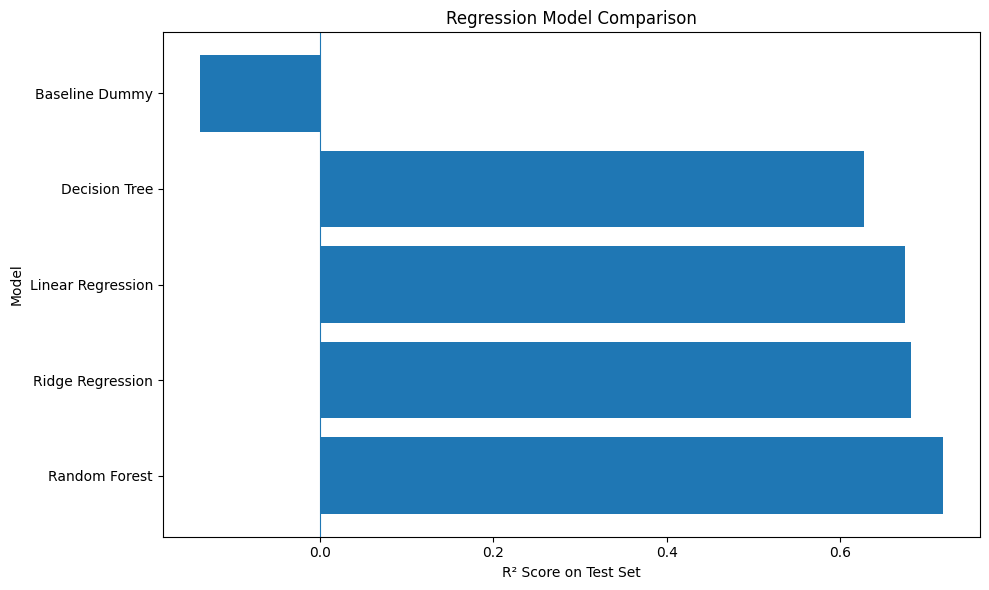

In [8]:
# ===== 7) Visualize model comparison =====

plt.figure(figsize=(10, 6))
plt.barh(model_results["Model"], model_results["R2"])
plt.xlabel("R² Score on Test Set")
plt.ylabel("Model")
plt.title("Regression Model Comparison")
plt.axvline(0, linewidth=0.8)
plt.tight_layout()
plt.savefig("figures/model_comparison_r2.png", dpi=300, bbox_inches="tight")
plt.show()

## 8) Cross-Validation for Random Forest

After model comparison, Random Forest is evaluated with 5-fold cross-validation on the training set.

Cross-validation provides a more stable estimate of model performance because the model is trained and validated on different subsets of the data. The training and validation scores are compared to check whether the model is overfitting.

**Lightweight adjustment:** 3-fold cross-validation and a smaller Random Forest are used to keep runtime manageable while still evaluating generalization.


In [21]:
# ===== 8) Cross-validation for Random Forest =====

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

kf = KFold(n_splits=3, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf_pipe,
    X_train,
    y_train,
    cv=kf,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    },
    return_train_score=True,
    n_jobs=-1
)

print("Random Forest Cross-Validation Results")
print("--------------------------------------")
print(f"Train R²: {cv_results['train_r2'].mean():.3f} ± {cv_results['train_r2'].std():.3f}")
print(f"Validation R²: {cv_results['test_r2'].mean():.3f} ± {cv_results['test_r2'].std():.3f}")
print(f"Validation MAE: {-cv_results['test_mae'].mean():.3f}")

Random Forest Cross-Validation Results
--------------------------------------
Train R²: 0.948 ± 0.003
Validation R²: 0.889 ± 0.011
Validation MAE: 2.020


## 9) Hyperparameter Tuning with GridSearchCV

GridSearchCV is used to tune the Random Forest model. The purpose is to test different combinations of hyperparameters and select the model with the best cross-validation performance.

The tuned parameters are:

- `n_estimators`: number of trees
- `max_depth`: maximum depth of each tree
- `min_samples_leaf`: minimum number of samples in a leaf node

The best model is then evaluated on the time-based test set.

**Lightweight adjustment:** A smaller parameter grid is used. This keeps the hyperparameter tuning step meaningful but much faster.


In [22]:
# ===== 9) GridSearchCV for Random Forest - lightweight version =====

param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [8, 10],
    "model__min_samples_leaf": [2, 3]
}

grid_search = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("Best CV R²:", round(grid_search.best_score_, 3))

best_rf = grid_search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters:
{'model__max_depth': 8, 'model__min_samples_leaf': 3, 'model__n_estimators': 50}
Best CV R²: 0.789


## 10) Final Random Forest Evaluation

The tuned Random Forest model is evaluated on the test set. Since the test set consists of the most recent years, the result shows how well the model generalizes to newer country-year observations.

The evaluation metrics are:

- **MAE:** average prediction error in years
- **RMSE:** prediction error with stronger penalty for large mistakes
- **R²:** proportion of variance explained by the model

In [12]:
# ===== 10) Final Random Forest evaluation =====

y_pred = best_rf.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = rmse(y_test, y_pred)
final_r2 = r2_score(y_test, y_pred)

print("Final Tuned Random Forest Results")
print("---------------------------------")
print("MAE:", round(final_mae, 3))
print("RMSE:", round(final_rmse, 3))
print("R²:", round(final_r2, 3))

Final Tuned Random Forest Results
---------------------------------
MAE: 2.658
RMSE: 4.024
R²: 0.715


## 11) Actual vs Predicted Values

The actual vs predicted plot shows how close the model's predictions are to the real life expectancy values.

Points close to the diagonal line represent accurate predictions. Points far from the line represent larger errors. If most points are close to the line, the model predicts life expectancy reasonably well.

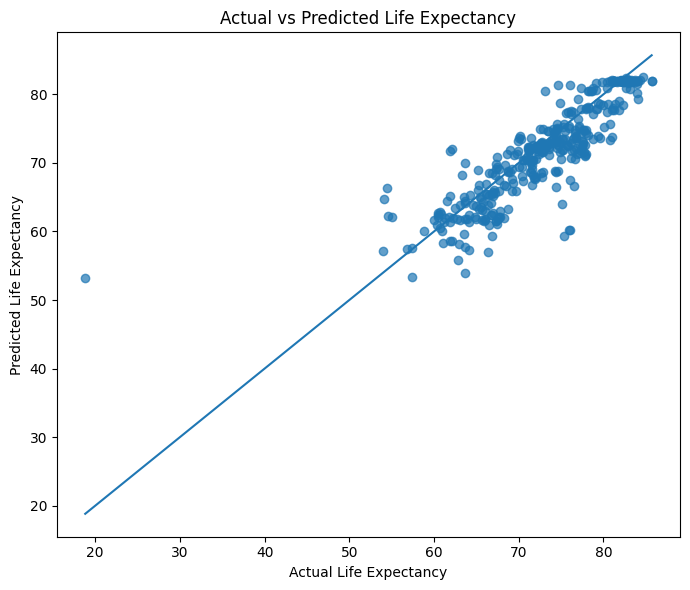

In [13]:
# ===== 11) Actual vs predicted plot =====

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")
plt.tight_layout()
plt.savefig("figures/actual_vs_predicted_life_expectancy.png", dpi=300, bbox_inches="tight")
plt.show()

## 12) Residual Analysis

Residuals are calculated as:

**Residual = Actual Life Expectancy − Predicted Life Expectancy**

Residual analysis helps identify whether the model makes systematic errors. Ideally, residuals should be centered around zero and should not show a strong pattern.

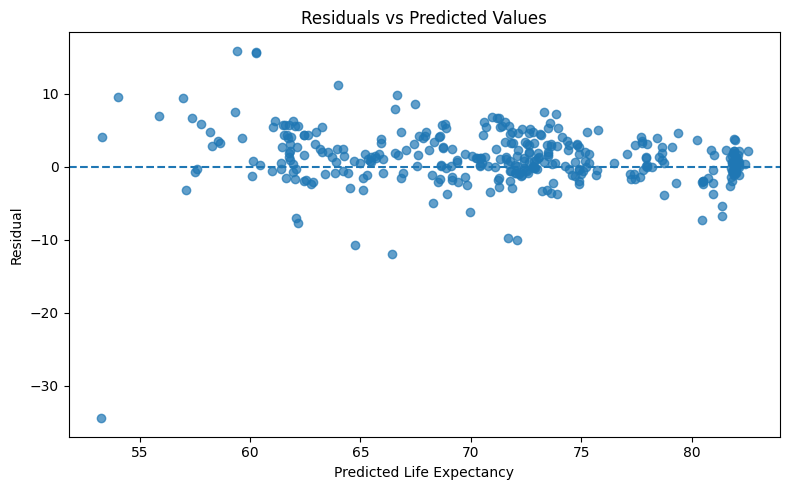

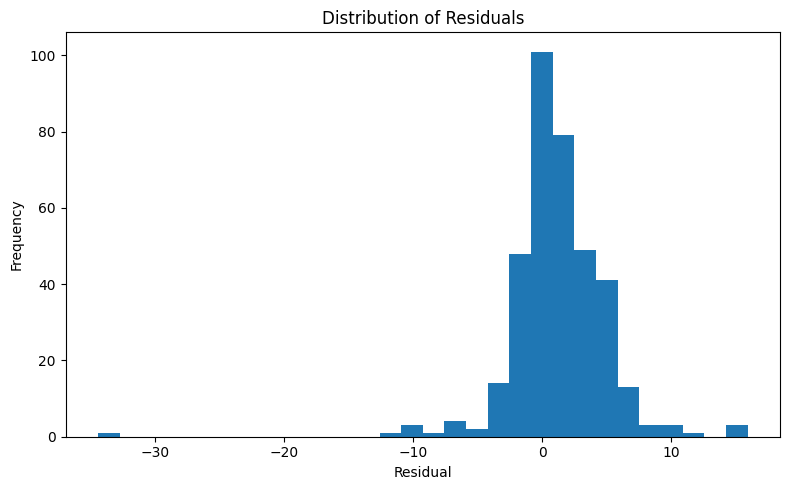

In [14]:
# ===== 12) Residual analysis =====

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Life Expectancy")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.savefig("figures/residuals_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.savefig("figures/residual_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 13) Largest Prediction Errors

The observations with the largest prediction errors are especially useful for interpretation.

Large errors may indicate countries or years where life expectancy is influenced by factors not included in the model, such as:

- education
- inequality
- war or political instability
- environmental conditions
- public health policy
- healthcare efficiency
- demographic structure

These cases help show the limitations of using only GDP and healthcare spending to explain health outcomes.

In [15]:
# ===== 13) Largest prediction errors =====

error_df = test_df.copy()
error_df["predicted_life_expectancy"] = y_pred
error_df["residual"] = residuals.values
error_df["absolute_error"] = np.abs(residuals.values)

largest_errors = error_df.sort_values("absolute_error", ascending=False).head(15)

display(largest_errors[[
    "Entity",
    "Code",
    "region",
    "Year",
    "life_expectancy",
    "predicted_life_expectancy",
    "absolute_error",
    "gdp_per_capita",
    "health_expenditure_per_capita"
]])

,Entity,Code,region,Year,life_expectancy,predicted_life_expectancy,absolute_error,gdp_per_capita,health_expenditure_per_capita
788,Central African Republic,CAF,Africa,2022,18.8177,53.249316,34.431616,1136.8018,124.917800
2679,Morocco,MAR,Africa,2023,75.3128,59.397308,15.915492,8915.3520,606.044250
765,Cape Verde,CPV,Africa,2023,76.0587,60.260138,15.798562,9228.4610,616.538400
764,Cape Verde,CPV,Africa,2022,75.9068,60.265417,15.641383,8850.1060,651.504760
2919,Nigeria,NGA,Africa,2023,54.4623,66.415491,11.953191,7843.8345,260.144620
2678,Morocco,MAR,Africa,2022,75.1614,63.963760,11.197640,8690.4480,542.223900
2918,Nigeria,NGA,Africa,2022,54.0790,64.756752,10.677752,7752.2620,250.453370
2775,Nauru,NRU,Oceania,2023,62.1094,72.068323,9.958923,12372.5205,2474.198000
4081,Tunisia,TUN,Africa,2023,76.5077,66.658050,9.849650,12650.9620,1112.514600
2774,Nauru,NRU,Oceania,2022,61.9304,71.683471,9.753071,12363.6455,2380.627000


## 14) Feature Importance

Feature importance is used to interpret which variables contribute most to the Random Forest model.

Because the model uses a preprocessing pipeline with one-hot encoded categorical variables, permutation importance is used. Permutation importance measures how much the model performance decreases when a feature is randomly shuffled.

A larger importance score means the feature is more influential for prediction.

,Feature,Importance Mean,Importance Std
7,region,1.464356e-01,2.459989e-02
1,gdp_per_capita,1.338549e-01,1.894131e-02
2,health_expenditure_per_capita,1.187282e-01,1.267225e-02
4,log_health_expenditure_per_capita,1.112309e-01,1.127185e-02
3,log_gdp_per_capita,7.362173e-02,1.178717e-02
5,gdp_to_health_ratio,5.759397e-03,5.667755e-03
6,health_share_proxy,1.353781e-04,6.923457e-03
0,Year,1.776357e-16,7.364386e-17


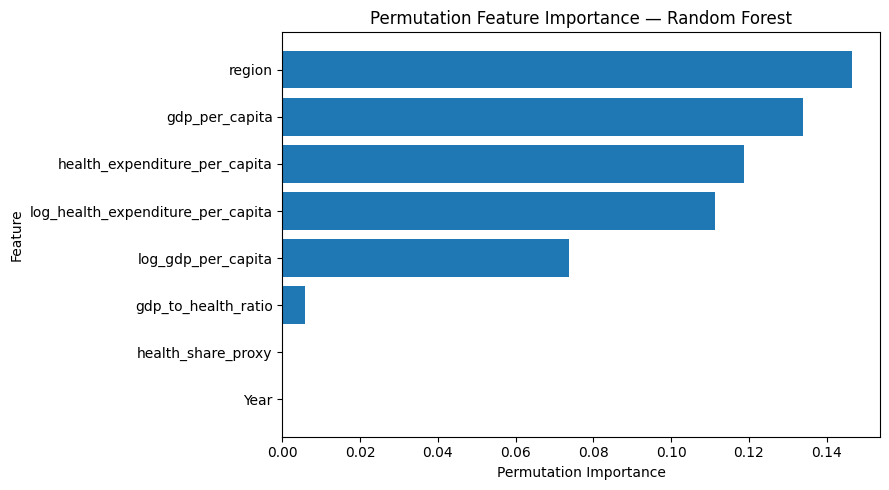

In [16]:
# ===== 14) Permutation feature importance =====

perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm.importances_mean,
    "Importance Std": perm.importances_std
}).sort_values("Importance Mean", ascending=False)

display(importance_df)

plt.figure(figsize=(9, 5))
plt.barh(importance_df["Feature"], importance_df["Importance Mean"])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance — Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/permutation_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 15) Learning Curve

A learning curve shows how model performance changes as the training data size increases.

If the training score is much higher than the validation score, the model may be overfitting. If both scores are low, the model may be underfitting. If validation performance improves as more data is added, this suggests that additional observations could improve model performance.

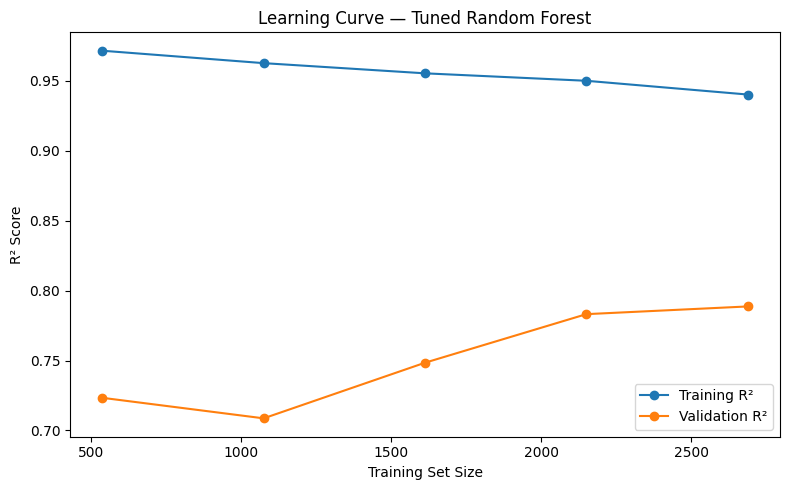

In [23]:
# ===== 15) Learning curve - lightweight version =====



train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=3,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training R²")
plt.plot(train_sizes, val_mean, marker="o", label="Validation R²")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve — Tuned Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("figures/learning_curve_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

## 16) Optional Classification Task: Life Expectancy Tiers

In addition to regression, a classification task is created by grouping life expectancy into three categories:

- Low life expectancy
- Middle life expectancy
- High life expectancy

This does not replace the regression task. Instead, it provides an additional way to evaluate whether economic and healthcare indicators can distinguish between countries with different health outcome levels.

Dummy Classifier Accuracy: 0.243
Random Forest Classifier Accuracy: 0.76
Random Forest Classifier Macro F1: 0.767

Classification Report:
              precision    recall  f1-score   support

        High       0.88      0.70      0.78       158
         Low       0.80      0.87      0.83        89
      Middle       0.63      0.76      0.69       120

    accuracy                           0.76       367
   macro avg       0.77      0.78      0.77       367
weighted avg       0.78      0.76      0.76       367



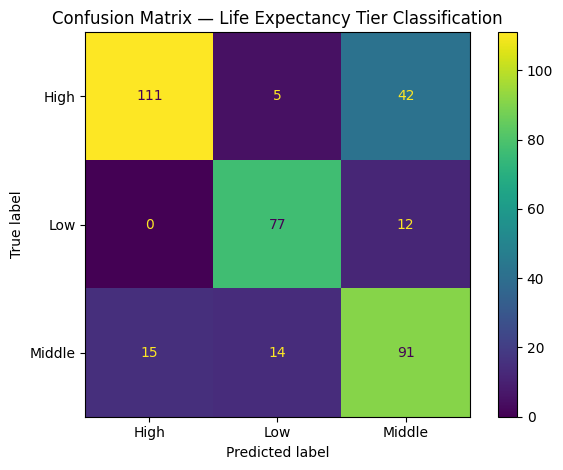

In [24]:
# ===== 16) Optional classification task =====

# Create tertile-based life expectancy groups
merged_df["life_expectancy_tier"] = pd.qcut(
    merged_df["life_expectancy"],
    q=3,
    labels=["Low", "Middle", "High"]
)

train_cls = merged_df[~merged_df["Year"].isin(test_years)].copy()
test_cls = merged_df[merged_df["Year"].isin(test_years)].copy()

X_train_cls = train_cls[numeric_features + categorical_features].copy()
y_train_cls = train_cls["life_expectancy_tier"]

X_test_cls = test_cls[numeric_features + categorical_features].copy()
y_test_cls = test_cls["life_expectancy_tier"]

cls_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

dummy_cls = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy_cls.fit(X_train_cls, y_train_cls)
cls_pipe.fit(X_train_cls, y_train_cls)

dummy_pred = dummy_cls.predict(X_test_cls)
cls_pred = cls_pipe.predict(X_test_cls)

print("Dummy Classifier Accuracy:", round(accuracy_score(y_test_cls, dummy_pred), 3))
print("Random Forest Classifier Accuracy:", round(accuracy_score(y_test_cls, cls_pred), 3))
print("Random Forest Classifier Macro F1:", round(f1_score(y_test_cls, cls_pred, average="macro"), 3))

print("\nClassification Report:")
print(classification_report(y_test_cls, cls_pred))

ConfusionMatrixDisplay.from_predictions(y_test_cls, cls_pred)
plt.title("Confusion Matrix — Life Expectancy Tier Classification")
plt.tight_layout()
plt.savefig("figures/confusion_matrix_life_expectancy_tiers.png", dpi=300, bbox_inches="tight")
plt.show()

## 17) Machine Learning Conclusion

The machine learning analysis shows that economic and healthcare-related indicators can be used to predict life expectancy across countries.

The model comparison step demonstrates whether more advanced models perform better than a simple baseline. The Dummy Regressor provides a minimum benchmark, while linear models, regularized models, and tree-based models provide stronger alternatives.

Random Forest Regression is especially useful for this project because it can capture non-linear relationships. This matters because the relationship between GDP, healthcare spending, and life expectancy is unlikely to be perfectly linear. For example, increases in income or health expenditure may have a stronger effect in lower-income countries than in already high-income countries.

The time-aware split makes the evaluation more realistic by training on earlier years and testing on the most recent years. The tuned Random Forest model is evaluated with MAE, RMSE, and R². The actual vs predicted plot and residual analysis show where the model performs well and where it struggles.

The largest prediction errors are also important because they point to the limitations of the model. Some countries may have higher or lower life expectancy than expected because of factors not included in the dataset, such as inequality, education, conflict, public health policy, healthcare efficiency, or environmental conditions.

Overall, the machine learning results support the project's main argument: GDP per capita and healthcare expenditure are meaningful predictors of life expectancy. However, the results should be interpreted as predictive relationships rather than causal proof. The model can identify patterns, but it cannot prove that GDP or healthcare spending directly causes higher life expectancy.